# dive-synthesized-7 — dive-6 (GraphCodeBERT, frozen) + synthetic-augmented 80/10/10

**This run.** Architecture and scaffold are *identical to dive-6*; the only change is the
**training data** — it loads the pre-split `dive-synthesized` dataset (80/10/10) whose
**train fold adds 6,138 synthetic source contracts** to lift the rare classes (Front
Running, Bad Randomness, DoS). Val/test are real-only and leakage-safe. Baseline to beat:
dive-6 test macro-F1 **0.768**.

**Why this notebook.** dive-2..5 were bytecode-only and trained the encoder
from scratch. The per-class picture at dive-5 (macro-F1 0.747) is dragged by
three classes whose ROC-AUC is high but precision/AP is low — Front Running
(F1 0.57, AUC 0.97), Bad Randomness (0.65, AUC 0.96), DoS (0.63). That
signature — *ranks well, calibrates badly* — is data scarcity, not an
architecture limit. We've also been ignoring the richest modality: the 22,330
Solidity **source** files, where the actual vulnerability fingerprints live
(`onlyOwner`, `require` placement, `block.timestamp`, `.call{value:}` ordering,
`tx.origin`).

dive-6 switches the input to source and uses a **pretrained** code model so the
rare classes inherit transfer priors instead of learning from ~450 positives.

## What's new vs dive-5

| Change | Why |
|---|---|
| **Modality: Solidity source** (was: EVM bytecode) | Source carries the densest, most direct vulnerability signal; bytecode mangles it. |
| **GraphCodeBERT-base, encoder-only, FROZEN** | Transfer learning is the standard low-resource fix and directly targets the rare-class precision ceiling. No Solidity data-flow extractor exists, so we use it as a code encoder (no DFG input). |
| **Function-level units** (split each contract into function/header units, <=256 tokens each) | GraphCodeBERT caps at 512 tokens; these flattened contracts have a median ~46 function/modifier decls. Vulnerabilities are mostly function-local, so this aligns with the signal. |
| **Two-stage (cache then train)** | End-to-end FT over ~46 units x 22k x 30 epochs is ~10-30x an 8h T4 budget. Stage 1 caches frozen unit embeddings once (forward-only); stage 2 trains a tiny aggregator in seconds/epoch. |
| **Set-Transformer aggregator** (no positional encoding, + unit-type embedding) | Unit order in flattened source is arbitrary -> permutation-invariant pooling is the correct prior. A 2-entry type embedding separates `contract`-header units (access-control / storage) from function units. |
| **Risk-ranked unit cap (MAX_UNITS=32)** | When a contract exceeds the cap, keep contract headers + functions ranked by visibility (`external/public/payable`) and risky sinks (`call/delegatecall/selfdestruct/block.timestamp/...`), so boilerplate getters drop before risky functions. |
| **Unit-dropout + unit-level CutMix** (replace token span-mask + token CutMix) | Augmentation now operates on the unit set, not tokens. |

## What stays identical to dive-5

- Multilabel-stratified 80/10/10 split, seed 42.
- AsymmetricLossWeighted (g-=4, g+=1, clip=0.05) + sqrt-inv-freq per-class
  weights clipped to [1,5], + 0.3*BCE aux head on (Bad Randomness, Front Running).
- EMA decay 0.999, AdamW with selective weight decay, cosine warmup, grad clip 1.0.
- WeightedRandomSampler (sqrt-inv-freq per-sample weights, clipped [1,5]).
- Per-class isotonic calibration on val -> 41-pt threshold tune (min-precision
  0.25 for classes with val support < 200).
- Atomic full-state checkpointing every epoch + every 30 min, tee logger,
  history.csv. **`torch.load(weights_only=False)`** baked in.

## Reading the result

1. **Gate logs (cells 4-8):** source coverage, units/contract, tokens/unit
   truncation, and the stage-1 timing estimate.
2. **`test_calibrated_tuned.f1_macro` vs dive-5's 0.7471** — the modality delta.
3. **Per-class F1 on Front Running / Bad Randomness / DoS** — the targeted
   classes; transfer learning is the lever.


## 1 — Environment

In [1]:
import os, re, gc, json, math, time, random, warnings, sys, traceback
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print(f"Torch {torch.__version__} | CUDA {torch.cuda.is_available()} | GPUs {n_gpus}", flush=True)
for i in range(n_gpus):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name} | {p.total_memory/1e9:.1f} GB | sm_{p.major}{p.minor}", flush=True)


Torch 2.10.0+cu128 | CUDA True | GPUs 2
  GPU 0: Tesla T4 | 15.6 GB | sm_75
  GPU 1: Tesla T4 | 15.6 GB | sm_75


In [2]:
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "iterative-stratification"])
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
    from transformers import AutoTokenizer, AutoModel
print("iterstrat + transformers ready", flush=True)


iterstrat + transformers ready


## 2 — Config

Edit **only** this cell to switch between fresh run and resume.

- `RESUME_FROM = None` -> fresh training, fresh checkpoint at `last_state.pt`.
- `RESUME_FROM = "/kaggle/working/last_state.pt"` -> continue from saved state.
  Optimizer / scheduler / scaler / RNG / EMA / epoch / history / best-metric /
  calibrators are restored. The stage-1 embedding cache (`dive_synth7_units.npz`) is
  reused if present, so resuming never re-encodes.


In [3]:
# -- Paths --------------------------------------------------------------------
def _find_root(base):
    base = Path(base)
    if not base.exists():
        return None
    hits = [h for h in base.rglob("train.csv") if h.parent.name == "splits"]
    return hits[0].parent.parent if hits else None

DATA_ROOT = (_find_root("/kaggle/input/datasets/henrychristian7555/dive-synthesized")
             or _find_root("/kaggle/input/dive-synthesized"))
if DATA_ROOT is None:
    import kagglehub
    DATA_ROOT = _find_root(kagglehub.dataset_download("henrychristian7555/dive-synthesized"))
assert DATA_ROOT is not None, "dive-synthesized dataset not found (no splits/train.csv under it)"

SPLIT_DIR   = DATA_ROOT / "splits"
REAL_SRC    = DATA_ROOT / "backup" / "Source"
SYNTH_SRC   = DATA_ROOT / "synthetic" / "Source_Synthetic"

def sol_path(cid):
    cid = int(cid)
    return (SYNTH_SRC / f"{cid}.sol") if cid >= 1_000_000 else (REAL_SRC / f"{cid}.sol")

OUT_DIR     = Path("/kaggle/working");   OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR   = OUT_DIR / "cache";         CACHE_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH    = OUT_DIR / "dive_synth7_train.log"
HIST_CSV    = OUT_DIR / "history.csv"
HIST_JSON   = OUT_DIR / "history.json"
STATE_PATH  = OUT_DIR / "last_state.pt"
BEST_PATH   = OUT_DIR / "best_model.pt"
EMB_NPZ     = CACHE_DIR / "dive_synth7_units.npz"

# -- Resume control -----------------------------------------------------------
RESUME_FROM = None    # set to str(STATE_PATH) to resume

# -- Labels -------------------------------------------------------------------
LABEL_COLS = ["Reentrancy", "Access Control", "Arithmetic", "Unchecked Return Values",
              "DoS", "Bad Randomness", "Front Running", "Time manipulation"]
N_LABELS = len(LABEL_COLS)
BR_IDX = LABEL_COLS.index("Bad Randomness")     # 5
FR_IDX = LABEL_COLS.index("Front Running")      # 6

# -- Stage 1: function-level units + frozen GraphCodeBERT ---------------------
GCB_MODEL    = "microsoft/graphcodebert-base"
EMB_DIM      = 768          # graphcodebert-base hidden size
MAX_UNITS    = 32           # function/header units per contract (risk-ranked cap)
UNIT_TOKENS  = 256          # GraphCodeBERT token cap per unit (<=512)
UNIT_CHAR_CAP = 2000        # pre-truncate unit text before tokenisation
HEADER_BASE_SCORE = 1000.0  # contract-header units outrank function units in the cap
GCB_BATCH    = 64           # units per GraphCodeBERT forward
GCB_FLUSH    = 2048         # units buffered before an encode flush (bounds RAM)

# -- Stage 2: set-Transformer aggregator --------------------------------------
D_MODEL   = 384
N_HEADS   = 6
N_LAYERS  = 3
D_FF      = 1024
DROPOUT   = 0.20
DROP_PATH = 0.10

# -- Training -----------------------------------------------------------------
BATCH_SIZE   = 128
EPOCHS       = 40
LR           = 3e-4
WEIGHT_DECAY = 0.05
GRAD_CLIP    = 1.0
WARMUP_RATIO = 0.10
PATIENCE     = 12
NUM_WORKERS  = 2
PIN_MEMORY   = True

# -- Asymmetric Loss + aux BCE ------------------------------------------------
ASL_GAMMA_NEG = 4.0
ASL_GAMMA_POS = 1.0
ASL_CLIP      = 0.05
PER_CLASS_W_MIN = 1.0
PER_CLASS_W_MAX = 5.0
AUX_BCE_INDICES = [BR_IDX, FR_IDX]
AUX_BCE_WEIGHT  = 0.3

# -- EMA ----------------------------------------------------------------------
EMA_DECAY = 0.999

# -- Augmentation (unit-level) ------------------------------------------------
AUG_UNIT_DROP_PROB = 0.10   # per real unit, drop (mask out) at train time
AUG_CUTMIX_PROB    = 0.30   # batch-level unit-slot CutMix
AUG_CUTMIX_BETA    = 0.5

# -- Sampler ------------------------------------------------------------------
SAMPLER_W_MIN = 1.0
SAMPLER_W_MAX = 5.0

# -- Checkpointing ------------------------------------------------------------
CKPT_WALLCLOCK_SECS = 30 * 60

# -- Verification gates -------------------------------------------------------
MIN_SOURCE_COVERAGE = 0.99        # >=99% of label rows must have a .sol file
MIN_UNIT_COVERAGE   = 0.99        # >=99% of contracts must yield >=1 unit
STAGE1_BUDGET_SECS  = 4 * 3600    # abort if estimated stage-1 encode exceeds this

# -- Sanity check on data files ----------------------------------------------
assert SPLIT_DIR.exists(), f"Missing splits dir {SPLIT_DIR}"
assert REAL_SRC.exists(),  f"Missing real source dir {REAL_SRC}"
assert SYNTH_SRC.exists(), f"Missing synthetic source dir {SYNTH_SRC}"
print("Inputs OK:", DATA_ROOT, flush=True)
print("RESUME_FROM:", RESUME_FROM, flush=True)
print(f"Stage1: MAX_UNITS={MAX_UNITS} UNIT_TOKENS={UNIT_TOKENS} model={GCB_MODEL}", flush=True)
print(f"Stage2: d_model={D_MODEL} n_heads={N_HEADS} n_layers={N_LAYERS} d_ff={D_FF}", flush=True)


Inputs OK: /kaggle/input/datasets/henrychristian7555/dive-synthesized/Dataset
RESUME_FROM: None
Stage1: MAX_UNITS=32 UNIT_TOKENS=256 model=microsoft/graphcodebert-base
Stage2: d_model=384 n_heads=6 n_layers=3 d_ff=1024


## 3 — `tee` logger

Mirrors stdout to `dive_synth7_train.log`. Survives Kaggle "Save Version" and is
reopened in append mode so it persists across resumes.


In [4]:
class TeeLogger:
    def __init__(self, path: Path):
        self.path = path
        self.fh = open(path, "a", buffering=1, encoding="utf-8")
        self.fh.write(f"\n===== run started {datetime.utcnow().isoformat()}Z =====\n")
        self.fh.flush()

    def __call__(self, msg: str = ""):
        ts = datetime.utcnow().strftime("%H:%M:%S")
        line = f"[{ts}] {msg}"
        print(line, flush=True)
        self.fh.write(line + "\n"); self.fh.flush()

    def close(self):
        try: self.fh.close()
        except Exception: pass

log = TeeLogger(LOG_PATH)
log(f"Logger writing to {LOG_PATH}")
log(f"GPUs available: {n_gpus}")


[09:41:39] Logger writing to /kaggle/working/dive_synth7_train.log
[09:41:39] GPUs available: 2


## 4 — Load frozen GraphCodeBERT ( verification gate #1 )

Pull `microsoft/graphcodebert-base` from HuggingFace ( internet must be on ),
freeze it, and confirm the hidden size matches `EMB_DIM`. We use it as a plain
code encoder: `input_ids` + `attention_mask` only, no data-flow-graph input.
Wrapped in `DataParallel` for the stage-1 encode so both T4s are used.


In [5]:
t0 = time.time()
gcb_tokenizer = AutoTokenizer.from_pretrained(GCB_MODEL)
# add_pooling_layer=False: we mean-pool last_hidden_state ourselves, so the
# RobertaModel CLS pooler is unused. Skipping it avoids a randomly-initialised
# unused head (the "pooler.dense MISSING" load warning) and a few extra params.
gcb = AutoModel.from_pretrained(GCB_MODEL, add_pooling_layer=False).to(device).eval()
for p in gcb.parameters():
    p.requires_grad_(False)

hidden = gcb.config.hidden_size
n_gcb = sum(p.numel() for p in gcb.parameters())
log(f"Loaded {GCB_MODEL} in {time.time()-t0:.1f}s | hidden={hidden} | params={n_gcb/1e6:.1f}M")
assert hidden == EMB_DIM, f"hidden_size {hidden} != EMB_DIM {EMB_DIM}"

gcb_dp = nn.DataParallel(gcb) if n_gpus > 1 else gcb


config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[09:41:48] Loaded microsoft/graphcodebert-base in 8.5s | hidden=768 | params=124.1M


## 5 — Load the pre-split folds ( verification gate #2 )

Load `train/val/test.csv` from the **dive-synthesized** dataset. `train` already
contains the 6,138 synthetic contracts (`contractID >= 1_000_000`); `val`/`test`
are real-only. Each row is filtered to those with a resolvable `.sol`
(real -> backup/Source, synthetic -> synthetic/Source_Synthetic); coverage is
expected to be 100%. **No re-splitting** — the folds are fixed and leakage-safe.


In [6]:
def _load_fold(name):
    d = pd.read_csv(SPLIT_DIR / f"{name}.csv")
    have = d["contractID"].apply(lambda c: sol_path(c).exists())
    cov = have.mean()
    log(f"  {name:>5s}: {len(d):6d} rows | source coverage {cov:.2%}")
    if cov < 1.0:
        log(f"    dropping {int((~have).sum())} rows with no .sol")
    return d[have].reset_index(drop=True)

train_df = _load_fold("train")
val_df   = _load_fold("val")
test_df  = _load_fold("test")

n_syn_eval = int((pd.concat([val_df, test_df])["contractID"] >= 1_000_000).sum())
assert n_syn_eval == 0, f"Leakage: {n_syn_eval} synthetic rows in val/test"

df = pd.concat([train_df, val_df, test_df], ignore_index=True)
log(f"Working set: {df.shape} | train synthetic={int((train_df['contractID']>=1_000_000).sum())}")
log("Positives per class (train fold):")
for c in LABEL_COLS:
    log(f"  {c:>26s}  {int(train_df[c].sum()):>5d}")


[09:42:03]   train:  22774 rows | source coverage 100.00%
[09:42:05]     val:   2847 rows | source coverage 100.00%
[09:42:07]    test:   2847 rows | source coverage 100.00%
[09:42:07] Working set: (28468, 9) | train synthetic=6138
[09:42:07] Positives per class (train fold):
[09:42:07]                   Reentrancy  13585
[09:42:07]               Access Control  18150
[09:42:07]                   Arithmetic  10062
[09:42:07]      Unchecked Return Values   4291
[09:42:07]                          DoS   5021
[09:42:07]               Bad Randomness   3511
[09:42:07]                Front Running   3527
[09:42:07]            Time manipulation   6303


## 6 — Fold indices ( pre-split, no re-splitting )

The folds come straight from the dataset; here we just build the integer index
arrays into `df` (train rows first, then val, then test) that the rest of the
notebook consumes, plus the multi-label target matrix `Y`.


In [7]:
Y = df[LABEL_COLS].values.astype(np.float32)

n_tr, n_v, n_te = len(train_df), len(val_df), len(test_df)
idx_tr = np.arange(0, n_tr)
idx_v  = np.arange(n_tr, n_tr + n_v)
idx_te = np.arange(n_tr + n_v, n_tr + n_v + n_te)

log(f"Train {len(idx_tr)} | Val {len(idx_v)} | Test {len(idx_te)}")
for i, lab in enumerate(LABEL_COLS):
    log(f"  {lab:>26s}  tr={int(Y[idx_tr,i].sum()):>5d}  "
        f"v={int(Y[idx_v,i].sum()):>4d}  te={int(Y[idx_te,i].sum()):>4d}")


[09:42:07] Train 22774 | Val 2847 | Test 2847
[09:42:07]                   Reentrancy  tr=13585  v=1562  te=1563
[09:42:07]               Access Control  tr=18150  v=2292  te=2292
[09:42:07]                   Arithmetic  tr=10062  v=1308  te=1308
[09:42:07]      Unchecked Return Values  tr= 4291  v= 810  te= 810
[09:42:07]                          DoS  tr= 5021  v= 518  te= 518
[09:42:07]               Bad Randomness  tr= 3511  v=  87  te=  87
[09:42:07]                Front Running  tr= 3527  v=  83  te=  83
[09:42:07]            Time manipulation  tr= 6303  v= 866  te= 867


## 7 — Solidity function splitter

Robust across pragma 0.4-0.8 ( brace-matching, not a version-pinned parser ).

1. **Mask** comments and string/char literals ( replace with spaces, preserve
   indices ) so brace/keyword scanning is never fooled by braces inside a
   comment or a `require(...)` message.
2. **Header units** — one per `contract` / `library` / `interface`: from the
   declaration to the first function-like keyword inside it ( captures
   inheritance, `using`-for, state vars, events, modifier *definitions* — i.e.
   the access-control + storage context ).
3. **Function units** — each `function` / `constructor` / `modifier` /
   `fallback` / `receive`, sliced to its matching `}` ( or `;` for abstract /
   interface declarations ).
4. **Risk-ranked cap** to `MAX_UNITS`: headers first ( finite high score so the
   most relevant headers win if a file has many ), then functions by visibility
   + risky-sink content + length. Kept units are returned in source order.


In [8]:
NL = chr(10); BS = chr(92); DQ = chr(34); SQ = chr(39)

BLOCK_RE = re.compile(r"\b(contract|library|interface)\b")
DECL_RE  = re.compile(r"\b(function|constructor|modifier|fallback|receive)\b")
VIS_RE   = re.compile(r"\b(external|public|payable)\b")
RISK_RE  = re.compile(r"delegatecall|callcode|selfdestruct|suicide|\.call|\.send|"
                      r"\.transfer|block\.timestamp|block\.number|blockhash|"
                      r"\btx\.origin\b|\bnow\b|ecrecover|assembly|sstore|create2")


def mask_comments_strings(src):
    """Blank out comments + string/char literals (same length) for safe scanning."""
    out = list(src); i = 0; n = len(src); st = 0; q = ""
    while i < n:
        c = src[i]; d = src[i + 1] if i + 1 < n else ""
        if st == 0:
            if c == "/" and d == "/": out[i] = " "; out[i + 1] = " "; i += 2; st = 1; continue
            if c == "/" and d == "*": out[i] = " "; out[i + 1] = " "; i += 2; st = 2; continue
            if c == DQ or c == SQ:    q = c; out[i] = " "; i += 1; st = 3; continue
            i += 1
        elif st == 1:
            if c == NL: st = 0; i += 1; continue
            out[i] = " "; i += 1
        elif st == 2:
            if c == "*" and d == "/": out[i] = " "; out[i + 1] = " "; i += 2; st = 0; continue
            if c != NL: out[i] = " "
            i += 1
        else:  # st == 3 : inside string/char literal
            if c == BS:
                out[i] = " "
                if i + 1 < n: out[i + 1] = " "
                i += 2; continue
            if c == q: out[i] = " "; st = 0; i += 1; continue
            if c != NL: out[i] = " "
            i += 1
    return "".join(out)


def match_brace(masked, open_pos):
    """Index of '}' matching the '{' at open_pos (inclusive), or last index."""
    depth = 0; n = len(masked); j = open_pos
    while j < n:
        ch = masked[j]
        if ch == "{": depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0: return j
        j += 1
    return n - 1


def split_solidity_units(src):
    """Return list of (start, text, is_function)."""
    masked = mask_comments_strings(src)
    units = []
    # contract/library/interface header units
    for bm in BLOCK_RE.finditer(masked):
        bstart = bm.start()
        bopen = masked.find("{", bm.end())
        if bopen == -1:
            units.append((bstart, src[bstart:bm.end()], False)); continue
        bclose = match_brace(masked, bopen)
        dm = DECL_RE.search(masked, bopen + 1, bclose)
        hdr_end = dm.start() if dm else bclose + 1
        units.append((bstart, src[bstart:hdr_end], False))
    # function-like units
    for m in DECL_RE.finditer(masked):
        start = m.start()
        brace = masked.find("{", m.end())
        semi  = masked.find(";", m.end())
        if brace == -1 and semi == -1:
            units.append((start, src[start:], True))
        elif semi != -1 and (brace == -1 or semi < brace):
            units.append((start, src[start:semi + 1], True))
        else:
            close = match_brace(masked, brace)
            units.append((start, src[start:close + 1], True))
    if not units:
        units = [(0, src[:UNIT_CHAR_CAP], False)]
    return units


def unit_score(text, is_function):
    if not is_function:
        return HEADER_BASE_SCORE + 50.0 * len(RISK_RE.findall(text))
    s = 10.0 * len(VIS_RE.findall(text)) + 50.0 * len(RISK_RE.findall(text))
    s += min(len(text), 4000) / 100.0
    return s


def cap_units(units, max_units=MAX_UNITS):
    if len(units) <= max_units:
        return sorted(units, key=lambda u: u[0])
    scored = sorted(units, key=lambda u: unit_score(u[1], u[2]), reverse=True)
    return sorted(scored[:max_units], key=lambda u: u[0])


def read_source(cid):
    try:
        return sol_path(cid).read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return ""


# Quick smoke test on a handful of contracts.
_smoke = []
for _cid in df["contractID"].head(20):
    _u = cap_units(split_solidity_units(read_source(_cid)))
    _smoke.append(len(_u))
log(f"Splitter smoke test on 20 contracts: units = {_smoke}")


[09:42:07] Splitter smoke test on 20 contracts: units = [32, 26, 32, 11, 32, 11, 7, 32, 32, 32, 9, 11, 32, 5, 11, 21, 26, 32, 20, 14]


## 8 — Stage-1: frozen GraphCodeBERT unit embeddings ( cached )

Single pass over all contracts. For each contract: split -> cap -> tokenise
each unit ( <=`UNIT_TOKENS`, truncated ) -> frozen GraphCodeBERT -> mean-pool
the final hidden state over real tokens into a 768-d vector. Units are buffered
( bounded RAM ) and encoded in `GCB_BATCH` mini-batches, written into a dense
`(N, MAX_UNITS, 768)` fp16 array.

**Verification gate #3** ( timing ): after the first flush we extrapolate total
encode time and assert it is under `STAGE1_BUDGET_SECS`. **Gate #4** ( units /
tokens ): logged distributions + asserts on unit coverage. Cache to `.npz`; a
resume reuses it and never re-encodes.


In [9]:
N = len(df)

if EMB_NPZ.exists():
    z = np.load(EMB_NPZ)
    UE, UM, UT = z["emb"], z["mask"], z["utype"]
    log(f"Loaded cached unit embeddings {UE.shape} {UE.dtype} from {EMB_NPZ.name}")
else:
    UE = np.zeros((N, MAX_UNITS, EMB_DIM), dtype=np.float16)
    UM = np.zeros((N, MAX_UNITS), dtype=np.bool_)
    UT = np.zeros((N, MAX_UNITS), dtype=np.int64)
    cids = df["contractID"].tolist()

    buf_text, buf_pos, tok_lens = [], [], []
    timing = {"done": False}

    def encode_flush():
        if not buf_text:
            return
        for s in range(0, len(buf_text), GCB_BATCH):
            tx = buf_text[s:s + GCB_BATCH]
            enc = gcb_tokenizer(tx, padding=True, truncation=True,
                                max_length=UNIT_TOKENS, return_tensors="pt")
            am = enc["attention_mask"]
            tok_lens.extend(am.sum(1).tolist())
            enc = {k: v.to(device, non_blocking=True) for k, v in enc.items()}
            with torch.no_grad(), autocast():
                hs = gcb_dp(**enc).last_hidden_state            # (b, T, 768)
            mf = enc["attention_mask"].unsqueeze(-1).float()
            pooled = (hs * mf).sum(1) / mf.sum(1).clamp(min=1.0)
            pooled = pooled.float().cpu().numpy().astype(np.float16)
            for (r, sl), vec in zip(buf_pos[s:s + GCB_BATCH], pooled):
                UE[r, sl] = vec
        buf_text.clear(); buf_pos.clear()

    t_start = time.time()
    for row in range(N):
        units = cap_units(split_solidity_units(read_source(cids[row])))
        for slot, (st, text, isf) in enumerate(units):
            UM[row, slot] = True
            UT[row, slot] = 1 if isf else 0
            buf_text.append(text[:UNIT_CHAR_CAP]); buf_pos.append((row, slot))
        if len(buf_text) >= GCB_FLUSH:
            n_before = len(buf_text); tf0 = time.time()
            encode_flush()
            if not timing["done"]:
                dt = time.time() - tf0
                upc = float(UM[:row + 1].sum()) / (row + 1)
                est_units = upc * N
                rate = n_before / max(dt, 1e-6)
                est_secs = est_units / max(rate, 1e-6)
                log(f"[stage1 timing] {n_before} units in {dt:.1f}s ({rate:.0f} units/s) "
                    f"-> est {est_units:,.0f} units total, ~{est_secs/60:.1f} min")
                assert est_secs < STAGE1_BUDGET_SECS, (
                    f"Estimated stage-1 encode {est_secs/3600:.2f}h exceeds budget "
                    f"{STAGE1_BUDGET_SECS/3600:.1f}h — lower MAX_UNITS / UNIT_TOKENS or raise STAGE1_BUDGET_SECS.")
                timing["done"] = True
        if row > 0 and row % 2000 == 0:
            log(f"  encoded {row}/{N} contracts | elapsed {time.time()-t_start:.0f}s")
    encode_flush()

    np.savez_compressed(EMB_NPZ, emb=UE, mask=UM, utype=UT)
    log(f"Stage-1 cache written -> {EMB_NPZ.name} | {time.time()-t_start:.0f}s total")

    tl = np.array(tok_lens)
    log(f"Tokens/unit: median={int(np.median(tl))}, p90={int(np.percentile(tl,90))}, "
        f"max={int(tl.max())} | truncated at {UNIT_TOKENS}: {(tl >= UNIT_TOKENS).mean():.2%}")

# -- unit-coverage gate -------------------------------------------------------
units_per = UM.sum(1)
log(f"Units/contract: median={int(np.median(units_per))}, "
    f"p90={int(np.percentile(units_per,90))}, max={int(units_per.max())}, "
    f"capped at {MAX_UNITS}: {(units_per >= MAX_UNITS).mean():.2%}, "
    f"zero-unit: {(units_per == 0).mean():.2%}")
assert (units_per >= 1).mean() >= MIN_UNIT_COVERAGE, \
    f"Only {(units_per>=1).mean():.2%} of contracts yielded >=1 unit — splitter or source problem."
log(f"Header-unit frac: {(UT[UM] == 0).mean():.2%} | function-unit frac: {(UT[UM] == 1).mean():.2%}")


[09:42:15] [stage1 timing] 2071 units in 6.1s (339 units/s) -> est 677,669 units total, ~33.3 min
[09:44:39]   encoded 2000/28468 contracts | elapsed 152s
[09:47:22]   encoded 4000/28468 contracts | elapsed 315s
[09:50:12]   encoded 6000/28468 contracts | elapsed 485s
[09:53:00]   encoded 8000/28468 contracts | elapsed 653s
[09:55:43]   encoded 10000/28468 contracts | elapsed 816s
[09:58:40]   encoded 12000/28468 contracts | elapsed 993s
[10:01:34]   encoded 14000/28468 contracts | elapsed 1167s
[10:04:26]   encoded 16000/28468 contracts | elapsed 1339s
[10:07:29]   encoded 18000/28468 contracts | elapsed 1522s
[10:10:28]   encoded 20000/28468 contracts | elapsed 1701s
[10:13:23]   encoded 22000/28468 contracts | elapsed 1876s
[10:16:13]   encoded 24000/28468 contracts | elapsed 2046s
[10:19:06]   encoded 26000/28468 contracts | elapsed 2219s
[10:21:56]   encoded 28000/28468 contracts | elapsed 2389s
[10:23:36] Stage-1 cache written -> dive_synth7_units.npz | 2489s total
[10:23:36] Tok

## 9 — Dataset + unit-dropout augmentation

`UE` is `(N, MAX_UNITS, 768)` fp16, `UM` is `(N, MAX_UNITS)` bool ( True = real
unit ), `UT` is `(N, MAX_UNITS)` int ( 0 = header, 1 = function ).

**Unit dropout** ( train only ): each real unit is masked out with probability
`AUG_UNIT_DROP_PROB`; at least one real unit is always kept. Forces the
aggregator to be robust to a missing function.


In [10]:
UE_tr, UM_tr, UT_tr, Y_tr = UE[idx_tr], UM[idx_tr], UT[idx_tr], Y[idx_tr]
UE_v,  UM_v,  UT_v,  Y_v  = UE[idx_v],  UM[idx_v],  UT[idx_v],  Y[idx_v]
UE_te, UM_te, UT_te, Y_te = UE[idx_te], UM[idx_te], UT[idx_te], Y[idx_te]
log(f"Tensors | UE_tr {UE_tr.shape} {UE_tr.dtype} | mean real-units (train) = {UM_tr.sum(1).mean():.1f}")


class UnitDS(Dataset):
    def __init__(self, E, M, T, Y, augment=False):
        self.E, self.M, self.T, self.Y = E, M, T, Y
        self.augment = augment

    def __len__(self):
        return len(self.E)

    def __getitem__(self, i):
        e = self.E[i].astype(np.float32)
        m = self.M[i].copy()
        t = self.T[i]
        if self.augment:
            real = np.where(m)[0]
            if len(real) > 1:
                drop = np.random.rand(len(real)) < AUG_UNIT_DROP_PROB
                m[real[drop]] = False
                if not m.any():
                    m[real[0]] = True
        return (torch.from_numpy(e),
                torch.from_numpy(m),
                torch.from_numpy(t.astype(np.int64)),
                torch.from_numpy(self.Y[i]))


ds_tr = UnitDS(UE_tr, UM_tr, UT_tr, Y_tr, augment=True)
ds_v  = UnitDS(UE_v,  UM_v,  UT_v,  Y_v,  augment=False)
ds_te = UnitDS(UE_te, UM_te, UT_te, Y_te, augment=False)
log(f"Datasets ready: train={len(ds_tr)} val={len(ds_v)} test={len(ds_te)}")
log(f"  aug: unit_drop={AUG_UNIT_DROP_PROB}, cutmix={AUG_CUTMIX_PROB} (beta={AUG_CUTMIX_BETA})")


[10:23:36] Tensors | UE_tr (22774, 32, 768) float16 | mean real-units (train) = 27.9
[10:23:36] Datasets ready: train=22774 val=2847 test=2847
[10:23:36]   aug: unit_drop=0.1, cutmix=0.3 (beta=0.5)


## 10 — Class-balanced sampler + unit-CutMix collate

**Sampler.** Per-sample weight = `max over positive labels of sqrt(N_total /
class_count)`, clipped to `[SAMPLER_W_MIN, SAMPLER_W_MAX]`. Same as dive-5.

**Unit-CutMix.** With probability `AUG_CUTMIX_PROB`, sample `lam ~ Beta(.5,.5)`,
pick `k = ceil(lam * MAX_UNITS)` random unit slots, and swap those slots'
( embedding, mask, type ) from a permuted partner. Labels mix by the ratio of
real units retained from `i` vs inserted from the partner.


In [11]:
def build_sampler_weights(Y_train: np.ndarray):
    counts = Y_train.sum(0).clip(min=1)
    inv = np.sqrt(Y_train.shape[0] / counts).astype(np.float32)
    has_pos = Y_train.sum(1) > 0
    w = np.where(has_pos, (Y_train * inv[None, :]).max(1), 1.0).astype(np.float32)
    w = np.clip(w, SAMPLER_W_MIN, SAMPLER_W_MAX)
    return w, inv, counts


sampler_w, inv_freq, class_counts = build_sampler_weights(Y_tr)
log("Per-class train counts and sqrt-inverse-freq weights:")
for i, lab in enumerate(LABEL_COLS):
    log(f"  {lab:>26s}  n={int(class_counts[i]):>5d}  inv_w={inv_freq[i]:.2f}")
log(f"Sampler weights: min={sampler_w.min():.2f}, median={np.median(sampler_w):.2f}, max={sampler_w.max():.2f}")

train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sampler_w).double(),
    num_samples=len(sampler_w),
    replacement=True,
)


def cutmix_collate_units(batch):
    E = torch.stack([b[0] for b in batch], dim=0)   # (B, U, 768)
    M = torch.stack([b[1] for b in batch], dim=0)   # (B, U) bool
    T = torch.stack([b[2] for b in batch], dim=0)   # (B, U) long
    Y = torch.stack([b[3] for b in batch], dim=0)   # (B, C)

    if AUG_CUTMIX_PROB <= 0 or np.random.rand() >= AUG_CUTMIX_PROB:
        return E, M, T, Y

    B, U, _ = E.shape
    perm = torch.randperm(B)
    lam = float(np.random.beta(AUG_CUTMIX_BETA, AUG_CUTMIX_BETA))
    k = int(np.ceil(lam * U)); k = max(1, min(U - 1, k))
    idx = torch.randperm(U)[:k]

    Em, Mm, Tm = E.clone(), M.clone(), T.clone()
    Em[:, idx] = E[perm][:, idx]
    Mm[:, idx] = M[perm][:, idx]
    Tm[:, idx] = T[perm][:, idx]

    keep_i = M.clone(); keep_i[:, idx] = False
    real_i = keep_i.float().sum(1)
    real_j = M[perm][:, idx].float().sum(1)
    total = (real_i + real_j).clamp(min=1.0)
    lam_eff = (real_i / total).unsqueeze(1)
    Ym = lam_eff * Y + (1.0 - lam_eff) * Y[perm]
    return Em, Mm, Tm, Ym


[10:23:36] Per-class train counts and sqrt-inverse-freq weights:
[10:23:36]                   Reentrancy  n=13585  inv_w=1.29
[10:23:36]               Access Control  n=18150  inv_w=1.12
[10:23:36]                   Arithmetic  n=10062  inv_w=1.50
[10:23:36]      Unchecked Return Values  n= 4291  inv_w=2.30
[10:23:36]                          DoS  n= 5021  inv_w=2.13
[10:23:36]               Bad Randomness  n= 3511  inv_w=2.55
[10:23:36]                Front Running  n= 3527  inv_w=2.54
[10:23:36]            Time manipulation  n= 6303  inv_w=1.90
[10:23:36] Sampler weights: min=1.00, median=2.13, max=2.55


## 11 — Model: set-Transformer aggregator + per-class heads + aux BCE

`unit_emb (B,U,768)` -> linear projection to `d_model` + a 2-entry unit-type
embedding ( header vs function ) -> `N_LAYERS` pre-norm Transformer blocks with
**no positional encoding** ( the unit set is order-arbitrary ) and a boolean
padding mask over units -> `mean (+) attn` pool over real units -> shared trunk
-> **8 parallel 2-layer MLP heads** + a `Linear(2d -> 2)` aux head for BR/FR.

Same head / pooling / aux design as dive-5 — only the front end changed
( projected frozen embeddings instead of a token embedding + CNN stem, and no
RoPE since there are no sequence positions ).


In [12]:
class DropPath(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        keep = 1.0 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = x.new_empty(shape).bernoulli_(keep)
        return x * mask / keep


class MHA(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.d = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=True)
        self.out = nn.Linear(d_model, d_model, bias=True)
        self.dropout = dropout

    def forward(self, x, attn_mask):
        B, U, D = x.shape
        qkv = self.qkv(x).reshape(B, U, 3, self.h, self.d).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        out = F.scaled_dot_product_attention(
            q, k, v, attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0, is_causal=False)
        out = out.transpose(1, 2).contiguous().reshape(B, U, D)
        return self.out(out)


class SetBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout, drop_path):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.mha = MHA(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model))
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
        self.dp1 = DropPath(drop_path)
        self.dp2 = DropPath(drop_path)

    def forward(self, x, attn_mask):
        x = x + self.dp1(self.drop1(self.mha(self.ln1(x), attn_mask)))
        x = x + self.dp2(self.drop2(self.ff(self.ln2(x))))
        return x


class UnitAggModel(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, num_classes=N_LABELS, d_model=D_MODEL,
                 n_heads=N_HEADS, n_layers=N_LAYERS, d_ff=D_FF,
                 dropout=DROPOUT, drop_path=DROP_PATH, aux_dim=2):
        super().__init__()
        self.in_proj  = nn.Linear(emb_dim, d_model)
        self.type_emb = nn.Embedding(2, d_model)
        self.in_norm  = nn.LayerNorm(d_model)
        self.in_drop  = nn.Dropout(dropout)

        dp_rates = [drop_path * i / max(1, n_layers - 1) for i in range(n_layers)]
        self.layers = nn.ModuleList([
            SetBlock(d_model, n_heads, d_ff, dropout, dp_rates[i]) for i in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model)
        self.attn_score = nn.Linear(d_model, 1)

        pool_dim = 2 * d_model
        self.head_shared = nn.Sequential(
            nn.LayerNorm(pool_dim), nn.Linear(pool_dim, d_model), nn.GELU(), nn.Dropout(dropout))
        self.class_heads = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Linear(d_model // 2, 1))
            for _ in range(num_classes)])
        self.aux_head = nn.Linear(pool_dim, aux_dim)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)

    def forward(self, unit_emb, unit_mask, unit_type):
        B, U, _ = unit_emb.shape
        x = self.in_proj(unit_emb) + self.type_emb(unit_type)
        x = self.in_drop(self.in_norm(x))

        attn_mask = unit_mask.view(B, 1, 1, U)          # bool, True = attend
        for layer in self.layers:
            x = layer(x, attn_mask)
        x = self.final_norm(x)

        mf = unit_mask.float().unsqueeze(-1)
        denom = mf.sum(1).clamp(min=1.0)
        mean_pool = (x * mf).sum(1) / denom

        s = self.attn_score(x).squeeze(-1).masked_fill(~unit_mask, -1e4)
        w = F.softmax(s, dim=-1).unsqueeze(-1)
        attn_pool = (x * w).sum(1)

        pooled = torch.cat([mean_pool, attn_pool], dim=-1)
        shared = self.head_shared(pooled)
        main_logits = torch.cat([h(shared) for h in self.class_heads], dim=-1)
        aux_logits  = self.aux_head(pooled)
        return main_logits, aux_logits


_m = UnitAggModel()
n_params = sum(p.numel() for p in _m.parameters())
log(f"Stage-2 trainable parameters: {n_params/1e6:.2f} M  ({n_params:,})")
del _m; gc.collect()


[10:23:37] Stage-2 trainable parameters: 5.33 M  (5,331,467)


0

## 12 — Loss: AsymmetricLoss ( per-class weighted ) + aux BCE on BR, FR

Verbatim from dive-5.


In [13]:
class AsymmetricLossWeighted(nn.Module):
    def __init__(self, class_weights: np.ndarray,
                 gamma_neg=ASL_GAMMA_NEG, gamma_pos=ASL_GAMMA_POS, clip=ASL_CLIP, eps=1e-8):
        super().__init__()
        self.register_buffer("class_weights", torch.from_numpy(class_weights.astype(np.float32)))
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        logits = logits.float()
        x_sig = torch.sigmoid(logits)
        xs_pos = x_sig
        xs_neg = 1.0 - x_sig
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)
        los_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1.0 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            pt0 = xs_pos * targets
            pt1 = xs_neg * (1.0 - targets)
            pt = pt0 + pt1
            one_sided_gamma = self.gamma_pos * targets + self.gamma_neg * (1.0 - targets)
            one_sided_w = torch.pow(1.0 - pt, one_sided_gamma)
            loss = loss * one_sided_w
        cw = self.class_weights.to(loss.device)
        loss = loss * cw.unsqueeze(0)
        return -loss.mean()


class ASLPlusAuxBCE(nn.Module):
    def __init__(self, asl: AsymmetricLossWeighted, aux_indices, aux_weight=AUX_BCE_WEIGHT):
        super().__init__()
        self.asl = asl
        self.register_buffer("aux_idx", torch.tensor(aux_indices, dtype=torch.long))
        self.aux_weight = float(aux_weight)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, main_logits, aux_logits, targets):
        main_loss = self.asl(main_logits, targets)
        aux_targets = targets.index_select(1, self.aux_idx.to(targets.device))
        aux_loss = self.bce(aux_logits.float(), aux_targets.float())
        return main_loss + self.aux_weight * aux_loss


_cw = np.sqrt(Y_tr.shape[0] / Y_tr.sum(0).clip(min=1)).astype(np.float32)
class_weights = np.clip(_cw, PER_CLASS_W_MIN, PER_CLASS_W_MAX)
class_weights = class_weights * (len(class_weights) / class_weights.sum())
log("Per-class loss weights (normalised, mean=1):")
for i, lab in enumerate(LABEL_COLS):
    log(f"  {lab:>26s}  w={class_weights[i]:.3f}")

criterion = ASLPlusAuxBCE(
    AsymmetricLossWeighted(class_weights),
    aux_indices=AUX_BCE_INDICES, aux_weight=AUX_BCE_WEIGHT).to(device)
log(f"Loss: ASL(g-={ASL_GAMMA_NEG}, g+={ASL_GAMMA_POS}, clip={ASL_CLIP}) "
    f"+ {AUX_BCE_WEIGHT} * BCE(aux on {AUX_BCE_INDICES})")


[10:23:37] Per-class loss weights (normalised, mean=1):
[10:23:37]                   Reentrancy  w=0.675
[10:23:37]               Access Control  w=0.584
[10:23:37]                   Arithmetic  w=0.785
[10:23:37]      Unchecked Return Values  w=1.201
[10:23:37]                          DoS  w=1.111
[10:23:37]               Bad Randomness  w=1.328
[10:23:37]                Front Running  w=1.325
[10:23:37]            Time manipulation  w=0.991
[10:23:37] Loss: ASL(g-=4.0, g+=1.0, clip=0.05) + 0.3 * BCE(aux on [5, 6])


## 13 — EMA

In [14]:
class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = EMA_DECAY):
        self.decay = decay
        src = model.module if isinstance(model, nn.DataParallel) else model
        self.ema = UnitAggModel().to(next(src.parameters()).device)
        self.ema.load_state_dict(src.state_dict())
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        src = model.module if isinstance(model, nn.DataParallel) else model
        msd = src.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1 - self.decay)
            else:
                v.copy_(msd[k])

    def state_dict(self):
        return self.ema.state_dict()

    def load_state_dict(self, sd):
        self.ema.load_state_dict(sd)


## 14 — Metrics, isotonic calibration, threshold tuning

Verbatim from dive-5.


In [15]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score,
                             hamming_loss, accuracy_score, confusion_matrix)
from sklearn.isotonic import IsotonicRegression


def multilabel_metrics(y_true, y_prob, thresholds):
    if np.isscalar(thresholds):
        thresholds = np.full(y_prob.shape[1], thresholds, dtype=np.float32)
    y_pred = (y_prob >= thresholds[None, :]).astype(np.int32)
    out = {
        "f1_micro":     f1_score(y_true, y_pred, average="micro",   zero_division=0),
        "f1_macro":     f1_score(y_true, y_pred, average="macro",   zero_division=0),
        "f1_samples":   f1_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "exact_match":  accuracy_score(y_true, y_pred),
    }
    per_class = {}
    for i, lab in enumerate(LABEL_COLS):
        yt, yp = y_true[:, i], y_pred[:, i]
        try:
            auc = roc_auc_score(yt, y_prob[:, i])
        except ValueError:
            auc = float("nan")
        per_class[lab] = {
            "support":   int(yt.sum()),
            "threshold": float(thresholds[i]),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall":    recall_score(yt, yp, zero_division=0),
            "f1":        f1_score(yt, yp, zero_division=0),
            "roc_auc":   auc,
            "ap":        average_precision_score(yt, y_prob[:, i]),
        }
    return out, per_class


def fit_isotonic_per_class(y_true, y_prob):
    calibrators = []
    for i in range(y_prob.shape[1]):
        iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
        if len(np.unique(y_true[:, i])) < 2:
            iso.fit([0.0, 1.0], [0.0, 1.0])
        else:
            iso.fit(y_prob[:, i], y_true[:, i])
        calibrators.append(iso)
    return calibrators


def apply_calibration(y_prob, calibrators):
    out = np.zeros_like(y_prob)
    for i, iso in enumerate(calibrators):
        out[:, i] = iso.transform(y_prob[:, i])
    return out


def tune_thresholds(y_true, y_prob, min_precision_rare=0.25, rare_support=200):
    grid = np.linspace(0.05, 0.95, 41)
    thresholds = np.full(y_prob.shape[1], 0.5, dtype=np.float32)
    for i in range(y_prob.shape[1]):
        support = int(y_true[:, i].sum())
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            pred = (y_prob[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], pred, zero_division=0)
            if support < rare_support:
                prec = precision_score(y_true[:, i], pred, zero_division=0)
                if prec < min_precision_rare:
                    continue
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[i] = best_t
    return thresholds


## 15 — Optimizer, cosine warmup, predict

In [16]:
def build_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY):
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or n.endswith(".bias") or "norm" in n.lower() or "emb" in n.lower():
            no_decay.append(p)
        else:
            decay.append(p)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=lr, betas=(0.9, 0.999), eps=1e-8)


def cosine_warmup(optimizer, total_steps, warmup_ratio=WARMUP_RATIO):
    warm = max(1, int(total_steps * warmup_ratio))
    def lr_lambda(step):
        if step < warm:
            return step / warm
        prog = (step - warm) / max(1, total_steps - warm)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    logits_all, labels_all = [], []
    for E, M, T, Yb in loader:
        E = E.to(device, non_blocking=True)
        M = M.to(device, non_blocking=True)
        T = T.to(device, non_blocking=True)
        with autocast():
            main_logits, _ = model(E, M, T)
        logits_all.append(main_logits.float().cpu().numpy())
        labels_all.append(Yb.numpy())
    return np.concatenate(logits_all), np.concatenate(labels_all)


## 16 — Dataloaders

In [17]:
train_loader = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          drop_last=True, persistent_workers=NUM_WORKERS > 0,
                          collate_fn=cutmix_collate_units)
val_loader   = DataLoader(ds_v,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
test_loader  = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
# non-augmented sequential pass over TRAIN, for overfit diagnostics (train vs val/test)
ds_tr_eval = UnitDS(UE_tr, UM_tr, UT_tr, Y_tr, augment=False)
train_eval_loader = DataLoader(ds_tr_eval, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
log(f"Batch size: {BATCH_SIZE} | steps/epoch: {len(train_loader)}, total: {len(train_loader)*EPOCHS}")


[10:23:37] Batch size: 128 | steps/epoch: 177, total: 7080


## 17 — Atomic checkpoint save / load ( full state )

`weights_only=False` is set explicitly — the payload bundles numpy threshold
arrays, numpy RNG state, and sklearn isotonic calibrators, which PyTorch >=2.6's
`weights_only=True` default rejects. These checkpoints are self-generated, so
loading them is trusted.


In [18]:
def _atomic_save(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_checkpoint(path, *, model, ema, optimizer, scheduler, scaler,
                    epoch, best_macro_f1, best_thresholds, history,
                    calibrators=None, extra=None):
    src = model.module if isinstance(model, nn.DataParallel) else model
    payload = {
        "model":     src.state_dict(),
        "ema":       ema.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler":    scaler.state_dict(),
        "epoch":     epoch,
        "best_macro_f1":   float(best_macro_f1),
        "best_thresholds": np.asarray(best_thresholds, dtype=np.float32).tolist(),
        "calibrators": calibrators,
        "history":   history,
        "rng": {
            "python": random.getstate(),
            "numpy":  np.random.get_state(),
            "torch":  torch.get_rng_state(),
            "cuda":   torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        },
        "config": {
            "EMB_DIM": EMB_DIM, "MAX_UNITS": MAX_UNITS, "UNIT_TOKENS": UNIT_TOKENS,
            "GCB_MODEL": GCB_MODEL,
            "D_MODEL": D_MODEL, "N_HEADS": N_HEADS, "N_LAYERS": N_LAYERS, "D_FF": D_FF,
            "DROPOUT": DROPOUT, "DROP_PATH": DROP_PATH, "BATCH_SIZE": BATCH_SIZE,
            "EPOCHS": EPOCHS, "LR": LR, "WEIGHT_DECAY": WEIGHT_DECAY,
            "ASL_GAMMA_NEG": ASL_GAMMA_NEG, "ASL_GAMMA_POS": ASL_GAMMA_POS,
            "ASL_CLIP": ASL_CLIP, "EMA_DECAY": EMA_DECAY,
            "AUG_UNIT_DROP_PROB": AUG_UNIT_DROP_PROB,
            "AUG_CUTMIX_PROB": AUG_CUTMIX_PROB, "AUG_CUTMIX_BETA": AUG_CUTMIX_BETA,
            "AUX_BCE_INDICES": AUX_BCE_INDICES, "AUX_BCE_WEIGHT": AUX_BCE_WEIGHT,
            "SEED": SEED, "class_weights": class_weights.tolist(),
        },
        "extra": extra or {},
    }
    _atomic_save(payload, Path(path))


def load_checkpoint(path, *, model, ema, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    src = model.module if isinstance(model, nn.DataParallel) else model
    src.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    rng = ckpt["rng"]
    random.setstate(rng["python"])
    np.random.set_state(rng["numpy"])
    torch.set_rng_state(rng["torch"])
    if rng["cuda"] is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(rng["cuda"])
    return ckpt


## 18 — Build model, optimiser, scheduler, scaler, EMA

In [19]:
model = UnitAggModel().to(device)
if n_gpus > 1:
    model = nn.DataParallel(model)
optimizer  = build_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler  = cosine_warmup(optimizer, total_steps, WARMUP_RATIO)
scaler     = GradScaler()
ema        = ModelEMA(model, decay=EMA_DECAY)

start_epoch = 1
best_macro_f1 = -1.0
best_thresholds = np.full(N_LABELS, 0.5, dtype=np.float32)
history = []
patience_left = PATIENCE

if RESUME_FROM is not None and Path(RESUME_FROM).exists():
    ckpt = load_checkpoint(RESUME_FROM, model=model, ema=ema,
                           optimizer=optimizer, scheduler=scheduler, scaler=scaler)
    start_epoch     = int(ckpt["epoch"]) + 1
    best_macro_f1   = float(ckpt["best_macro_f1"])
    best_thresholds = np.asarray(ckpt["best_thresholds"], dtype=np.float32)
    history         = list(ckpt["history"])
    log(f"RESUMED from {RESUME_FROM}: epoch {ckpt['epoch']} -> continuing at {start_epoch}")
    log(f"  best so far: macro_f1={best_macro_f1:.4f}")
else:
    log("Starting fresh (RESUME_FROM is None or missing)")

log(f"Optimizer ready | total_steps={total_steps} | warmup={int(total_steps*WARMUP_RATIO)}")


[10:23:37] Starting fresh (RESUME_FROM is None or missing)
[10:23:37] Optimizer ready | total_steps=7080 | warmup=708


## 19 — Training loop

Per epoch: train ( sampler + unit-CutMix + AMP + grad-clip + cosine LR + EMA )
-> validate on EMA ( predict -> fit isotonic on val -> tune thresholds ) ->
atomic full-state save -> `best_model.pt` on each new best -> wall-clock
snapshot every 30 min -> early stop after `PATIENCE` non-improvements.


In [20]:
HEARTBEAT_STEPS = 50


def _run_epoch(epoch):
    model.train()
    t0 = time.time()
    n_steps = len(train_loader)
    running_loss = 0.0
    running_n = 0

    for step, (E, M, T, Yb) in enumerate(train_loader, 1):
        E  = E.to(device,  non_blocking=True)
        M  = M.to(device,  non_blocking=True)
        T  = T.to(device,  non_blocking=True)
        Yb = Yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            main_logits, aux_logits = model(E, M, T)
            loss = criterion(main_logits, aux_logits, Yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)

        running_loss += loss.item(); running_n += 1
        if step % HEARTBEAT_STEPS == 0 or step == n_steps:
            cur_lr = optimizer.param_groups[0]["lr"]
            avg = running_loss / running_n
            elapsed = time.time() - t0
            eta = elapsed * (n_steps / step - 1)
            log(f"  epoch {epoch:2d}  step {step:>4d}/{n_steps} | "
                f"loss={avg:.4f} | lr={cur_lr:.2e} | elapsed={elapsed:5.1f}s eta={eta:5.1f}s")
    return running_loss / max(1, running_n), time.time() - t0


def _flush_history():
    pd.DataFrame(history).to_csv(HIST_CSV, index=False)
    with open(HIST_JSON, "w") as f:
        json.dump(history, f, indent=2)


last_ckpt_ts = time.time()
epoch_save_done = False
best_calibrators = None

try:
    for epoch in range(start_epoch, EPOCHS + 1):
        epoch_save_done = False
        train_loss, train_dt = _run_epoch(epoch)

        val_logits, val_labels = predict(ema.ema, val_loader)
        val_probs_raw = 1 / (1 + np.exp(-val_logits))
        calibrators = fit_isotonic_per_class(val_labels, val_probs_raw)
        val_probs   = apply_calibration(val_probs_raw, calibrators)
        val_thr     = tune_thresholds(val_labels, val_probs)
        val_metrics, _ = multilabel_metrics(val_labels, val_probs, val_thr)
        val_metrics_raw_05, _ = multilabel_metrics(val_labels, val_probs_raw, 0.5)

        # train metrics (non-augmented, raw@0.5) — apples-to-apples vs val raw@0.5 for the overfit watch
        tr_logits, tr_labels = predict(ema.ema, train_eval_loader)
        train_metrics_raw_05, _ = multilabel_metrics(tr_labels, 1 / (1 + np.exp(-tr_logits)), 0.5)
        overfit_gap = train_metrics_raw_05["f1_macro"] - val_metrics_raw_05["f1_macro"]
        cur_lr = optimizer.param_groups[0]["lr"]

        log(f"Epoch {epoch:2d}/{EPOCHS} | train_dt={train_dt:5.1f}s | lr={cur_lr:.2e} | "
            f"train_loss={train_loss:.4f} | f1_macro raw@0.5 "
            f"train={train_metrics_raw_05['f1_macro']:.4f} val={val_metrics_raw_05['f1_macro']:.4f} "
            f"(gap={overfit_gap:+.4f}) | EMA val calib+thr f1_macro={val_metrics['f1_macro']:.4f} "
            f"f1_micro={val_metrics['f1_micro']:.4f} ham={val_metrics['hamming_loss']:.4f}")

        history.append({
            "epoch": epoch, "train_loss": train_loss, "lr": cur_lr,
            "train_dt": train_dt, **val_metrics,
            "val_f1_macro_raw_05": val_metrics_raw_05["f1_macro"],
            "train_f1_macro_raw_05": train_metrics_raw_05["f1_macro"],
            "overfit_gap_f1_macro_raw_05": overfit_gap,
        })
        _flush_history()

        save_checkpoint(STATE_PATH, model=model, ema=ema,
                        optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                        epoch=epoch, best_macro_f1=best_macro_f1,
                        best_thresholds=best_thresholds, history=history,
                        calibrators=calibrators)
        epoch_save_done = True

        if val_metrics["f1_macro"] > best_macro_f1:
            best_macro_f1 = val_metrics["f1_macro"]
            best_thresholds = val_thr.copy()
            best_calibrators = calibrators
            _atomic_save({"model": ema.state_dict(),
                          "thresholds": best_thresholds,
                          "calibrators": calibrators,
                          "epoch": epoch,
                          "val_metrics": val_metrics}, BEST_PATH)
            log(f"  * NEW BEST EMA macro-F1={best_macro_f1:.4f} -> {BEST_PATH.name}")
            patience_left = PATIENCE
        else:
            patience_left -= 1
            log(f"  no improvement (best={best_macro_f1:.4f}, patience={patience_left}/{PATIENCE})")

        if time.time() - last_ckpt_ts >= CKPT_WALLCLOCK_SECS:
            snap = OUT_DIR / f"state_epoch{epoch:02d}.pt"
            save_checkpoint(snap, model=model, ema=ema,
                            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                            epoch=epoch, best_macro_f1=best_macro_f1,
                            best_thresholds=best_thresholds, history=history,
                            calibrators=calibrators)
            log(f"  wall-clock snapshot -> {snap.name}")
            last_ckpt_ts = time.time()

        if patience_left <= 0:
            log(f"Early stopping at epoch {epoch} (no EMA macro-F1 improvement for {PATIENCE} epochs)")
            break

    log(f"Training done. Best EMA val macro-F1 = {best_macro_f1:.4f}")

except Exception as e:
    log("!! Exception during training — flushing state before re-raising")
    log(traceback.format_exc())
    try:
        if 'epoch' in locals() and not epoch_save_done:
            crash_epoch = max(0, epoch - 1)
            save_checkpoint(STATE_PATH, model=model, ema=ema,
                            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                            epoch=crash_epoch, best_macro_f1=best_macro_f1,
                            best_thresholds=best_thresholds, history=history,
                            calibrators=best_calibrators, extra={"error": repr(e)})
            log(f"State flushed at epoch={crash_epoch} -> {STATE_PATH}. "
                f"Set RESUME_FROM='{STATE_PATH}' and re-run.")
        else:
            log(f"Most recent successful save in {STATE_PATH} preserved.")
    except Exception as e2:
        log(f"Also failed to flush state: {e2!r}")
    raise
finally:
    _flush_history()


[10:23:41]   epoch  1  step   50/177 | loss=0.2883 | lr=2.12e-05 | elapsed=  3.8s eta=  9.5s
[10:23:44]   epoch  1  step  100/177 | loss=0.2697 | lr=4.24e-05 | elapsed=  6.4s eta=  5.0s
[10:23:46]   epoch  1  step  150/177 | loss=0.2595 | lr=6.36e-05 | elapsed=  9.1s eta=  1.6s
[10:23:48]   epoch  1  step  177/177 | loss=0.2477 | lr=7.50e-05 | elapsed= 10.4s eta=  0.0s
[10:23:53] Epoch  1/40 | train_dt= 10.4s | lr=7.50e-05 | train_loss=0.2477 | f1_macro raw@0.5 train=0.4653 val=0.4427 (gap=+0.0226) | EMA val calib+thr f1_macro=0.4662 f1_micro=0.6626 ham=0.3010
[10:23:53]   * NEW BEST EMA macro-F1=0.4662 -> best_model.pt
[10:23:56]   epoch  2  step   50/177 | loss=0.1441 | lr=9.62e-05 | elapsed=  2.8s eta=  7.1s
[10:23:59]   epoch  2  step  100/177 | loss=0.1383 | lr=1.17e-04 | elapsed=  5.3s eta=  4.1s
[10:24:01]   epoch  2  step  150/177 | loss=0.1316 | lr=1.39e-04 | elapsed=  8.0s eta=  1.4s
[10:24:03]   epoch  2  step  177/177 | loss=0.1288 | lr=1.50e-04 | elapsed=  9.4s eta=  0.0s


## 20 — Test evaluation ( calibrated + frozen thresholds )

Load `best_model.pt` ( EMA weights + isotonic calibrators + frozen thresholds ),
apply calibration to test probs, then frozen thresholds. Report calibrated+tuned
( deployed ), calibrated @ 0.5, and raw @ 0.5. `weights_only=False` set here too.


In [21]:
log("=== TEST EVAL ===")
if not BEST_PATH.exists():
    log("No best_model.pt found — falling back to current EMA weights and last calibrators.")
    eval_model = ema.ema
    frozen_thresholds = best_thresholds
    frozen_calibrators = best_calibrators
else:
    ckpt_b = torch.load(BEST_PATH, map_location=device, weights_only=False)
    eval_model = UnitAggModel().to(device)
    eval_model.load_state_dict(ckpt_b["model"])
    frozen_thresholds = np.asarray(ckpt_b["thresholds"], dtype=np.float32)
    frozen_calibrators = ckpt_b["calibrators"]
    log(f"Loaded best model from epoch {ckpt_b.get('epoch','?')}: "
        f"val_f1_macro={ckpt_b.get('val_metrics',{}).get('f1_macro','?')}")

if n_gpus > 1 and not isinstance(eval_model, nn.DataParallel):
    eval_model = nn.DataParallel(eval_model)

test_logits, test_labels_arr = predict(eval_model, test_loader)
test_probs_raw = 1 / (1 + np.exp(-test_logits))
test_probs     = apply_calibration(test_probs_raw, frozen_calibrators)

test_metrics_tuned, per_class_tuned = multilabel_metrics(test_labels_arr, test_probs, frozen_thresholds)
test_metrics_calib_05, _            = multilabel_metrics(test_labels_arr, test_probs, 0.5)
test_metrics_raw_05, _              = multilabel_metrics(test_labels_arr, test_probs_raw, 0.5)

log("=== TEST METRICS (calibrated + frozen per-class tuned thresholds) ===")
for k, v in test_metrics_tuned.items():
    log(f"  {k:>16s}: {v:.4f}")
log("=== TEST METRICS (calibrated @ 0.5) ===")
for k, v in test_metrics_calib_05.items():
    log(f"  {k:>16s}: {v:.4f}")
log("=== TEST METRICS (raw @ 0.5 — no calibration, no tuning) ===")
for k, v in test_metrics_raw_05.items():
    log(f"  {k:>16s}: {v:.4f}")

pc_df = pd.DataFrame(per_class_tuned).T.round(4)
log("=== PER-CLASS (calibrated + tuned thresholds) ===")
for line in pc_df.to_string().splitlines():
    log("  " + line)

np.save(OUT_DIR / "test_probs_calibrated.npy", test_probs)
np.save(OUT_DIR / "test_probs_raw.npy",        test_probs_raw)
np.save(OUT_DIR / "test_labels.npy",           test_labels_arr)
np.save(OUT_DIR / "thresholds.npy",            frozen_thresholds)
pc_df.to_csv(OUT_DIR / "per_class.csv")

with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump({
        "test_calibrated_tuned":  test_metrics_tuned,
        "test_calibrated_at_0.5": test_metrics_calib_05,
        "test_raw_at_0.5":        test_metrics_raw_05,
        "per_class":              per_class_tuned,
        "best_val_f1_macro":      best_macro_f1,
        "thresholds":             frozen_thresholds.tolist(),
        "hparams": {
            "emb_dim": EMB_DIM, "max_units": MAX_UNITS, "unit_tokens": UNIT_TOKENS,
            "gcb_model": GCB_MODEL,
            "d_model": D_MODEL, "n_heads": N_HEADS, "n_layers": N_LAYERS, "d_ff": D_FF,
            "dropout": DROPOUT, "drop_path": DROP_PATH,
            "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr": LR,
            "weight_decay": WEIGHT_DECAY, "warmup_ratio": WARMUP_RATIO, "grad_clip": GRAD_CLIP,
            "asl_gamma_neg": ASL_GAMMA_NEG, "asl_gamma_pos": ASL_GAMMA_POS, "asl_clip": ASL_CLIP,
            "ema_decay": EMA_DECAY,
            "aug_unit_drop_prob": AUG_UNIT_DROP_PROB,
            "aug_cutmix_prob": AUG_CUTMIX_PROB, "aug_cutmix_beta": AUG_CUTMIX_BETA,
            "aux_bce_indices": AUX_BCE_INDICES, "aux_bce_weight": AUX_BCE_WEIGHT,
            "sampler_w_min": SAMPLER_W_MIN, "sampler_w_max": SAMPLER_W_MAX,
            "per_class_w_min": PER_CLASS_W_MIN, "per_class_w_max": PER_CLASS_W_MAX,
            "class_weights": class_weights.tolist(),
            "patience": PATIENCE, "seed": SEED,
        }}, f, indent=2)

cms = {}
y_pred_final = (test_probs >= frozen_thresholds[None, :]).astype(np.int32)
for i, lab in enumerate(LABEL_COLS):
    cm = confusion_matrix(test_labels_arr[:, i], y_pred_final[:, i], labels=[0, 1])
    cms[lab] = cm.tolist()
with open(OUT_DIR / "confusion_per_class.json", "w") as f:
    json.dump(cms, f, indent=2)


[10:33:19] === TEST EVAL ===
[10:33:19] Loaded best model from epoch 40: val_f1_macro=0.7807604108519992
[10:33:20] === TEST METRICS (calibrated + frozen per-class tuned thresholds) ===
[10:33:20]           f1_micro: 0.8477
[10:33:20]           f1_macro: 0.7906
[10:33:20]         f1_samples: 0.7948
[10:33:20]       hamming_loss: 0.1073
[10:33:20]        exact_match: 0.5167
[10:33:20] === TEST METRICS (calibrated @ 0.5) ===
[10:33:20]           f1_micro: 0.8467
[10:33:20]           f1_macro: 0.7779
[10:33:20]         f1_samples: 0.7870
[10:33:20]       hamming_loss: 0.1036
[10:33:20]        exact_match: 0.5297
[10:33:20] === TEST METRICS (raw @ 0.5 — no calibration, no tuning) ===
[10:33:20]           f1_micro: 0.8218
[10:33:20]           f1_macro: 0.7604
[10:33:20]         f1_samples: 0.7844
[10:33:20]       hamming_loss: 0.1384
[10:33:20]        exact_match: 0.4162
[10:33:20] === PER-CLASS (calibrated + tuned thresholds) ===
[10:33:20]                            support  threshold  pr

## 20b — Metrics graphics: train / val / test ( overfit check )

Two figures, saved to `/kaggle/working/` and shown inline:
1. **Training curves** — `train_loss` plus train vs val macro-F1 (raw@0.5,
   apples-to-apples) and the deployed val macro-F1 (calibrated + tuned).
   Train F1 climbing while val F1 flattens/drops = overfitting.
2. **Per-class F1 bars across train / val / test** at the best model
   (calibrated + frozen thresholds). A large train >> val/test gap = overfitting.


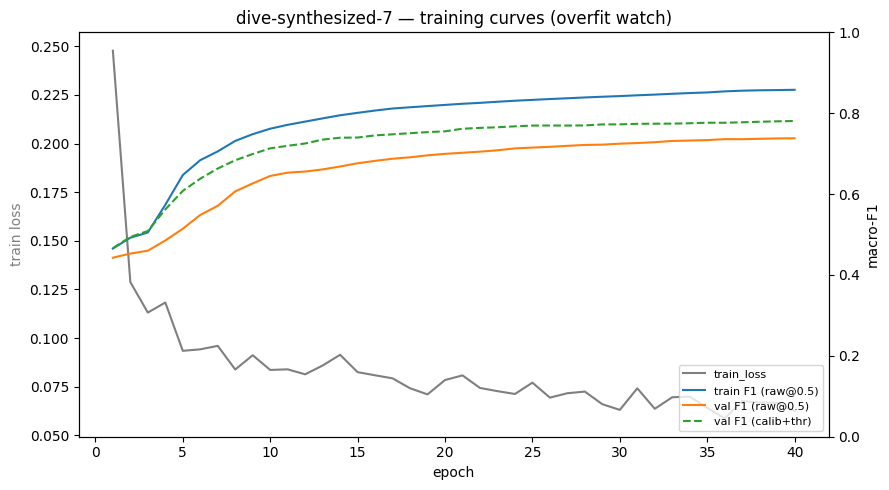

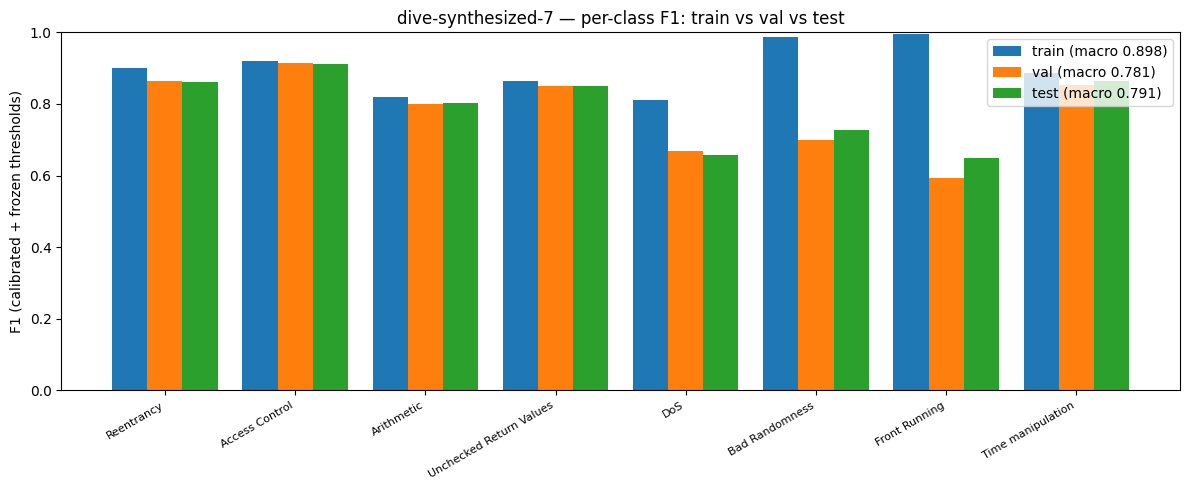

[10:33:27] Saved graphics: curves_overfit.png, per_class_f1_train_val_test.png, f1_train_val_test.csv
[10:33:27] macro-F1 (calib+thr)  train=0.8979  val=0.7806  test=0.7906  (train-test gap=+0.1073)


In [22]:
try:
    import matplotlib.pyplot as plt

    hist = pd.DataFrame(history)

    # (1) training curves: loss + train/val macro-F1 (raw@0.5, apples-to-apples)
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(hist["epoch"], hist["train_loss"], color="tab:gray", label="train_loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("train loss", color="tab:gray")
    ax2 = ax1.twinx()
    if "train_f1_macro_raw_05" in hist:
        ax2.plot(hist["epoch"], hist["train_f1_macro_raw_05"], color="tab:blue", label="train F1 (raw@0.5)")
    ax2.plot(hist["epoch"], hist["val_f1_macro_raw_05"], color="tab:orange", label="val F1 (raw@0.5)")
    ax2.plot(hist["epoch"], hist["f1_macro"], color="tab:green", linestyle="--", label="val F1 (calib+thr)")
    ax2.set_ylabel("macro-F1"); ax2.set_ylim(0, 1)
    lines = ax1.get_lines() + ax2.get_lines()
    ax2.legend(lines, [ln.get_label() for ln in lines], loc="lower right", fontsize=8)
    plt.title("dive-synthesized-7 — training curves (overfit watch)")
    fig.tight_layout(); fig.savefig(OUT_DIR / "curves_overfit.png", dpi=120); plt.show(); plt.close(fig)

    # (2) per-class F1 across train / val / test at the best model (calibrated + frozen thresholds)
    def _fold_f1(loader):
        lg, lb = predict(eval_model, loader)
        pr = apply_calibration(1 / (1 + np.exp(-lg)), frozen_calibrators)
        _, pc = multilabel_metrics(lb, pr, frozen_thresholds)
        return [pc[c]["f1"] for c in LABEL_COLS]

    f1_train = _fold_f1(train_eval_loader)
    f1_val   = _fold_f1(val_loader)
    f1_test  = [per_class_tuned[c]["f1"] for c in LABEL_COLS]

    x = np.arange(N_LABELS); bw = 0.27
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - bw, f1_train, bw, label=f"train (macro {np.mean(f1_train):.3f})")
    ax.bar(x,      f1_val,   bw, label=f"val (macro {np.mean(f1_val):.3f})")
    ax.bar(x + bw, f1_test,  bw, label=f"test (macro {np.mean(f1_test):.3f})")
    ax.set_xticks(x); ax.set_xticklabels(LABEL_COLS, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("F1 (calibrated + frozen thresholds)"); ax.set_ylim(0, 1)
    ax.set_title("dive-synthesized-7 — per-class F1: train vs val vs test")
    ax.legend(); fig.tight_layout()
    fig.savefig(OUT_DIR / "per_class_f1_train_val_test.png", dpi=120); plt.show(); plt.close(fig)

    pd.DataFrame({"class": LABEL_COLS, "f1_train": f1_train, "f1_val": f1_val, "f1_test": f1_test}).to_csv(OUT_DIR / "f1_train_val_test.csv", index=False)
    log("Saved graphics: curves_overfit.png, per_class_f1_train_val_test.png, f1_train_val_test.csv")
    log(f"macro-F1 (calib+thr)  train={np.mean(f1_train):.4f}  val={np.mean(f1_val):.4f}  test={np.mean(f1_test):.4f}  (train-test gap={np.mean(f1_train)-np.mean(f1_test):+.4f})")
except Exception as e:
    log(f"Metrics plotting skipped due to error: {e!r}")


## 21 — End-to-end inference check

Deployment path for a **new** contract ( no cache ): raw source -> split into
units -> frozen GraphCodeBERT encode -> aggregator -> isotonic calibration ->
per-class thresholds -> multi-label prediction. The GraphCodeBERT encode
dominates latency, so the benchmark times the whole path ( batch=1, single GPU ).
A small qualitative demo prints predicted vs true labels for a few test
contracts.


In [23]:
infer_model = eval_model.module if isinstance(eval_model, nn.DataParallel) else eval_model
infer_model.eval(); gcb.eval()


@torch.no_grad()
def infer_contract(src_text):
    units = cap_units(split_solidity_units(src_text))
    texts = [t[:UNIT_CHAR_CAP] for (_, t, _) in units]
    types = [1 if isf else 0 for (_, _, isf) in units]

    enc = gcb_tokenizer(texts, padding=True, truncation=True,
                        max_length=UNIT_TOKENS, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with autocast():
        hs = gcb(**enc).last_hidden_state
    mf = enc["attention_mask"].unsqueeze(-1).float()
    embs = ((hs * mf).sum(1) / mf.sum(1).clamp(min=1.0)).float()

    U = MAX_UNITS
    n = min(len(units), U)
    e  = torch.zeros(1, U, EMB_DIM, device=device)
    m  = torch.zeros(1, U, dtype=torch.bool, device=device)
    tt = torch.zeros(1, U, dtype=torch.long, device=device)
    e[0, :n]  = embs[:n]
    m[0, :n]  = True
    tt[0, :n] = torch.tensor(types[:n], device=device)

    with autocast():
        main_logits, _ = infer_model(e, m, tt)
    raw = torch.sigmoid(main_logits).float().cpu().numpy()[0]
    cal = np.array([frozen_calibrators[i].transform([raw[i]])[0] for i in range(N_LABELS)])
    pred = (cal >= frozen_thresholds).astype(int)
    return cal, pred


rng = np.random.RandomState(0)
demo_rows = rng.choice(idx_te, size=8, replace=False)
log("=== INFERENCE DEMO (predicted vs true) ===")
for row in demo_rows:
    cid = int(df.iloc[row]["contractID"])
    cal, pred = infer_contract(read_source(cid))
    true = Y[row].astype(int)
    pl = [LABEL_COLS[i] for i in range(N_LABELS) if pred[i]]
    tl = [LABEL_COLS[i] for i in range(N_LABELS) if true[i]]
    tag = "OK  " if (pred == true).all() else "DIFF"
    log(f"  [{tag}] contract {cid}")
    log(f"        pred: {pl}")
    log(f"        true: {tl}")


BENCH_N = 256
bench_rows = rng.choice(idx_te, size=min(BENCH_N, len(idx_te)), replace=False)
bench_src = [read_source(int(df.iloc[r]["contractID"])) for r in bench_rows]

for s in bench_src[:8]:        # warmup
    infer_contract(s)
if torch.cuda.is_available():
    torch.cuda.synchronize()

lat = []
for s in bench_src:
    t0 = time.time()
    infer_contract(s)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    lat.append((time.time() - t0) * 1000.0)
lat = np.array(lat)

dev = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
log("=== INFERENCE BENCHMARK (end-to-end: split + GraphCodeBERT + aggregator, batch=1) ===")
log(f"   device: {dev}")
log(f"   n_samples: {len(lat)}")
log(f"      p50_ms: {np.percentile(lat,50):.2f}")
log(f"      p90_ms: {np.percentile(lat,90):.2f}")
log(f"     mean_ms: {lat.mean():.2f}")
log(f"      max_ms: {lat.max():.2f}")

with open(OUT_DIR / "inference_bench.json", "w") as f:
    json.dump({"device": dev, "n_samples": int(len(lat)),
               "p50_ms": float(np.percentile(lat, 50)), "p90_ms": float(np.percentile(lat, 90)),
               "mean_ms": float(lat.mean()), "max_ms": float(lat.max())}, f, indent=2)
log("Wrote inference_bench.json")


[10:33:27] === INFERENCE DEMO (predicted vs true) ===
[10:33:27]   [OK  ] contract 12938
[10:33:27]         pred: ['Access Control', 'Arithmetic']
[10:33:27]         true: ['Access Control', 'Arithmetic']
[10:33:27]   [DIFF] contract 21183
[10:33:27]         pred: ['Reentrancy', 'Access Control', 'Arithmetic', 'Unchecked Return Values']
[10:33:27]         true: ['Reentrancy', 'Arithmetic', 'Unchecked Return Values']
[10:33:27]   [OK  ] contract 1824
[10:33:27]         pred: ['Access Control', 'Unchecked Return Values']
[10:33:27]         true: ['Access Control', 'Unchecked Return Values']
[10:33:27]   [DIFF] contract 912
[10:33:27]         pred: ['Access Control', 'Arithmetic']
[10:33:27]         true: ['Reentrancy', 'Access Control', 'Arithmetic']
[10:33:27]   [DIFF] contract 19428
[10:33:27]         pred: ['Reentrancy', 'Access Control', 'Arithmetic', 'DoS', 'Front Running']
[10:33:27]         true: ['Reentrancy', 'Access Control', 'DoS', 'Front Running']
[10:33:27]   [DIFF] contract

## Summary

**dive-6 = modality switch + transfer learning.** Source instead of bytecode;
a frozen pretrained code model instead of a from-scratch encoder.

**Pipeline.**
1. Split each `.sol` into function/header units ( brace-matching, robust across
   0.4-0.8 ), risk-ranked cap to `MAX_UNITS=32`.
2. Frozen GraphCodeBERT mean-pools each unit ( <=256 tokens ) into a 768-d
   vector — cached once to `dive_synth7_units.npz`.
3. A small set-Transformer aggregates the unit set ( permutation-invariant, +
   unit-type embedding ) and feeds dive-5's exact head ( 8 per-class MLPs + aux
   BCE on BR/FR ), trained with the same loss / sampler / EMA / calibration /
   threshold-tuning / checkpointing.

**Outputs (`/kaggle/working/`).**
- `cache/dive_synth7_units.npz` — frozen unit embeddings ( reused on resume ).
- `best_model.pt` — EMA weights + calibrators + frozen thresholds.
- `last_state.pt` — full resumable state ( `RESUME_FROM` ).
- `metrics.json`, `per_class.csv`, `history.csv`, `dive_synth7_train.log`.

**What to look at.**
1. Gate logs: source coverage, units/contract, tokens/unit truncation, stage-1
   timing estimate.
2. `test_calibrated_tuned.f1_macro` vs dive-5's 0.7471.
3. Per-class F1 on Front Running / Bad Randomness / DoS — the transfer-learning
   targets.

**If you later want more accuracy** ( dive-7 ): unfreeze the top GraphCodeBERT
layers for end-to-end fine-tuning ( hard-cap units, gradient checkpointing ), or
fuse this source model with the dive-5 bytecode model + transaction features.
